Test and debug functions from fmatoolbox

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import fmatoolbox as fma
import regions as rg
import matplotlib.pyplot as plt

In [2]:
session = '/mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml'
R = rg.data.Regions(session,states=['sws','rem'],events=['ripples'])

In [3]:
R.eventIntervals([['sleeps','sws'],['ripples']])

array([[  245.7008,   245.7296],
       [  245.8104,   245.8352],
       [  246.7376,   246.8   ],
       ...,
       [26399.7   , 26399.7224],
       [26399.8192, 26399.8496],
       [26405.3632, 26405.388 ]], shape=(2363, 2))

In [4]:
R.units(regs=['pfc','nr'])

array([47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63,
       64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80,
       81,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
       33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46])

In [5]:
R.spikes(regs='pfc',state='sws')

array([[  243.60605,    81.     ],
       [  243.62   ,    65.     ],
       [  243.62245,    78.     ],
       ...,
       [26407.9803 ,    63.     ],
       [26407.98685,    75.     ],
       [26407.9891 ,    48.     ]], shape=(575955, 2))

In [6]:
R.firingRate(regs=['nr','pfc'],states=['rem'])

array([[  474.025,   120.   ,   200.   ],
       [  474.075,   240.   ,   140.   ],
       [  474.125,   260.   ,   120.   ],
       ...,
       [26424.425,   140.   ,   100.   ],
       [26424.475,   180.   ,   200.   ],
       [26424.525,   200.   ,   120.   ]], shape=(27964, 3))

In [7]:
R.unitFiringRate(regs=['pfc','nr'],states=['rem'])

array([[4.7402500e+02, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [4.7407500e+02, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        4.0000000e+01, 0.0000000e+00],
       [4.7412500e+02, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 4.0000000e+01],
       ...,
       [2.6424425e+04, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [2.6424475e+04, 0.0000000e+00, 4.0000000e+01, ..., 0.0000000e+00,
        2.0000000e+01, 0.0000000e+00],
       [2.6424525e+04, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]], shape=(27964, 83))

In [3]:
size, intervals, size_t = R.avalanches(thresh=30)
durations = {reg: np.diff(intervals[reg]) for reg in size}

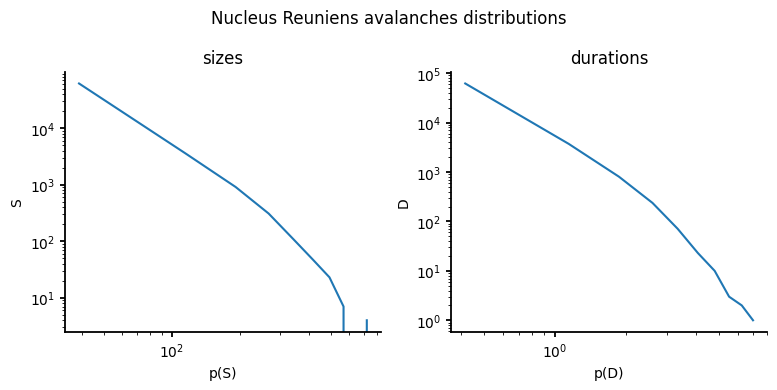

In [ ]:
reg = 'nr'
fig, axs = fma.plotting.makeFigure('Nucleus Reuniens avalanches distributions',[1,2],[20,10])
titles = ['sizes','durations']
xlabels = ['p(S)','p(D)']
ylabels = ['S','D']
for i, obj in enumerate([size[reg],durations[reg]]):
    distr, edges = np.histogram(obj)
    centers = (edges[:-1]+edges[1:]) / 2 # convert bin edges to bin centers
    axs[i].loglog(centers,distr); axs[i].set_title(titles[i]); axs[i].set_xlabel(xlabels[i]); axs[i].set_ylabel(ylabels[i])
fig.tight_layout()

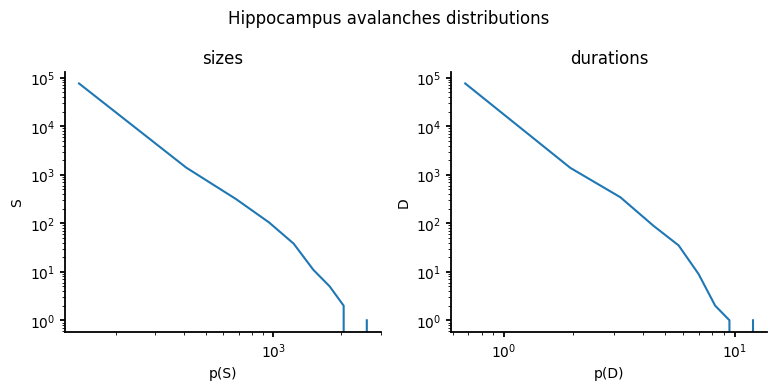

In [ ]:
reg = 'hpc'
fig, axs = fma.plotting.makeFigure('Hippocampus avalanches distributions',[1,2],[20,10])
titles = ['sizes','durations']
xlabels = ['p(S)','p(D)']
ylabels = ['S','D']
for i, obj in enumerate([size[reg],durations[reg]]):
    distr, edges = np.histogram(obj)
    centers = (edges[:-1]+edges[1:]) / 2 # convert bin edges to bin centers
    axs[i].loglog(centers,distr); axs[i].set_title(titles[i]); axs[i].set_xlabel(xlabels[i]); axs[i].set_ylabel(ylabels[i])
fig.tight_layout()

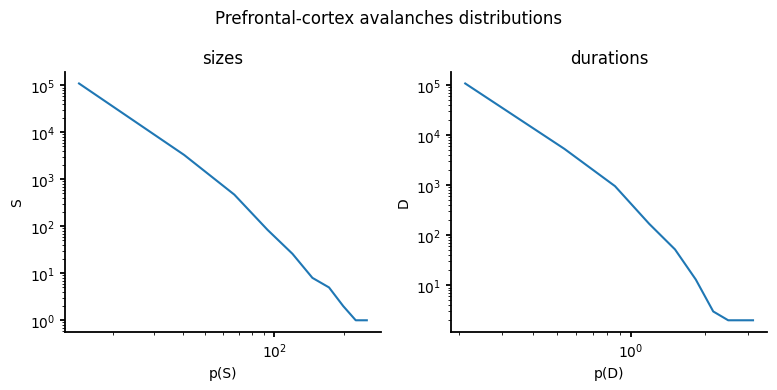

In [ ]:
reg = 'pfc'
fig, axs = fma.plotting.makeFigure('Prefrontal-cortex avalanches distributions',[1,2],[20,10])
titles = ['sizes','durations']
xlabels = ['p(S)','p(D)']
ylabels = ['S','D']
for i, obj in enumerate([size[reg],durations[reg]]):
    distr, edges = np.histogram(obj)
    centers = (edges[:-1]+edges[1:]) / 2 # convert bin edges to bin centers
    axs[i].loglog(centers,distr); axs[i].set_title(titles[i]); axs[i].set_xlabel(xlabels[i]); axs[i].set_ylabel(ylabels[i])
fig.tight_layout()